# Tugas 3 Machine Learning Pre-Processing Data

Nama : Lusia Clara Sianturi

NIM : 2304010019

# Titanic Dataset

Konteks : Dataset ini berisi data penumpang kapal Titanic dengan tujuan memprediski apakah penumpang selamat (survived)

Variabel yang digunakan adalah:

- Survived : target (0 = tidak selamat, 1 = selamat)
- Pclass : kelas tiket
- Sex : jenis kelamin
- Age : umur
- Fare : harga tiket
- Embarked : pelabuhan naik

### Import Library & Load Data (Data Retrieval)

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/Titanic-Dataset.csv')

# Lihat 5 data pertama
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Menampilkan contoh data untuk memahami struktur awal dataset.

In [166]:
df.shape

(891, 12)

Output (891, 12)
Artinya terdapat 891 observasi atau penumpang dengan 12 variabel

### Cek Informasi Data (Data Understanding)

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [168]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Age : rata-rata sekitar 29 tahun yang merupakan mayoritas usia produktif

Fare : memiliki range sangat besar yang dapat mengindikasikan outlier

SibSp & Parch : sebagian besar bernilai 0 yang artinya banyak penumpang yang naik kapal seorang diri.


Data tersebut tidak terdistribusi normal (khususnya Fare) sehingga perlu scaling dan kemungkinan transformasi.

In [169]:
(df.isnull().sum() / len(df)) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Cabin : 77% kosong yang berarti tidak representatif sehingga wajar untuk dihapus.

Age : 20% kosong, namun masih bisa diimputasi

Embarked : sangat kecil sehingga aman jika diisi dengan modus data.

### Data Cleaning (Handling Missing Values)

In [170]:
# Isi missing Age dengan median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Isi Embarked dengan modus
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin karena terlalu banyak missing
df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()

/tmp/ipykernel_31240/3605783330.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_31240/3605783330.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


- Age diisi dengan median karena distribusi cenderung skew atau tidak simetris, median lebih tahan terhadap outlier.

- Embarked diisi dengan modus karena data termasuk kategorikal dan untuk mempertahankan distribusi kategori.

- Cabin didrop karena missing yang terlalu besar yang dapat menyebabkan bias.

### Exploratory Data Analysis (EDA)

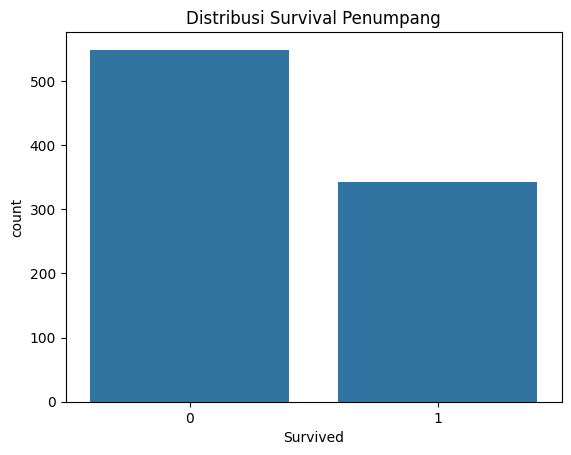

In [171]:
sns.countplot(x='Survived', data=df)
plt.title('Distribusi Survival Penumpang')
plt.show()

Grafik tersebut menunjukkan jumlah penumpang yang selamat vs tidak selamat.
Kelas 0 menunjukkan grafik penumpang yang tidak selamat lebih banyak daripada kelas 1 untuk penumpang yang selamat.

Dapat diartikan dataset tidak seimbang (imbalanced)

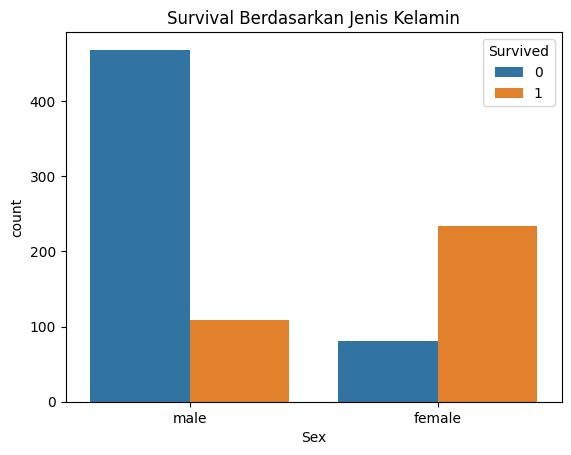

In [172]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Berdasarkan Jenis Kelamin')
plt.show()

Grafik tersebut menunjukkan perbandingan survival berdasarkan gender. Terlihat Perempuan lebih banyak yang selamat.

Ada faktor prioritas penyelamatan (women and children first)

### Feature Engineering

In [173]:
# Membuat fitur baru: Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


Menggabungkan informasi keluarga menjadi satu variabel dan mengurangi kompleksitas fitur.

Insight:
Family size kecil menunjukkan survival yang lebih tinggi, jika terlalu besar justru menurunkan peluang untuk selamat.

### Encoding (Ubah Kategorikal ke Numerik)

In [174]:
# Ubah Sex
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

# One-hot encoding Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,2,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,2,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,1,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,2,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,1,False,True


Mengubah kategori menjadi numerik, tidak menambah dimensi fitur.

Untuk menghindari dummy variable trap dengan mengubah kategori menjadi variabel independen.

### Feature Selection

In [175]:
# Drop kolom yang tidak relevan
df.drop(columns=['Name','Ticket','PassengerId'], inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,False,True
1,1,1,1,38.0,1,0,71.2833,2,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,2,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


In [176]:
df.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
Survived,1.000000,-0.338481,0.543351,-0.064910,-0.035322,0.081629,0.257307,0.016639,0.003650,-0.149683
Pclass,-0.338481,1.000000,-0.131900,-0.339898,0.083081,0.018443,-0.549500,0.065997,0.221009,0.074053
Sex,0.543351,-0.131900,1.000000,-0.081163,0.114631,0.245489,0.182333,0.200988,0.074115,-0.119224
Age,-0.064910,-0.339898,-0.081163,1.000000,-0.233296,-0.172482,0.096688,-0.245619,-0.031415,-0.006729
SibSp,-0.035322,0.083081,0.114631,-0.233296,1.000000,0.414838,0.159651,0.890712,-0.026354,0.068734
Parch,0.081629,0.018443,0.245489,-0.172482,0.414838,1.000000,0.216225,0.783111,-0.081228,0.060814
Fare,0.257307,-0.549500,0.182333,0.096688,0.159651,0.216225,1.000000,0.217138,-0.117216,-0.162184
FamilySize,0.016639,0.065997,0.200988,-0.245619,0.890712,0.783111,0.217138,1.000000,-0.058592,0.077359
Embarked_Q,0.003650,0.221009,0.074115,-0.031415,-0.026354,-0.081228,-0.117216,-0.058592,1.000000,-0.499421
Embarked_S,-0.149683,0.074053,-0.119224,-0.006729,0.068734,0.060814,-0.162184,0.077359,-0.499421,1.000000


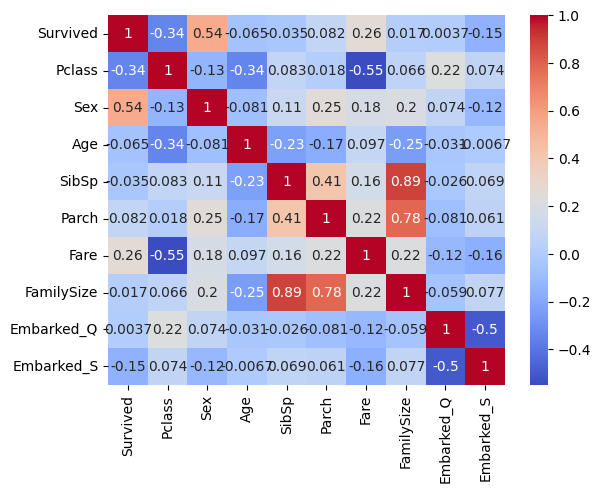

In [177]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Melihat hubungan antar variabel. Survived berkorelasi dengan variabel Sex, Fare, Pclass.

Drop kolom dilakukan karena variabel Name, Ticket, PassengerId tidak memiliki hubungan langsung dengan survival yang bersifat identifier/noise.

### Feature Scaling

In [178]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_cols = ['Age','Fare','FamilySize']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

Mengubah skala data jadi standar (mean=0, std=1). Hal ini penting dilakukan untuk algoritma Meachine Learning seperti Logistic Regression, KNN, SVM yang sensitif terhadap skala.

### Dataset Siap Modeling

In [179]:
X = df.drop('Survived', axis=1)
y = df['Survived']

x = variabel independen

y =  variabel dependen


In [180]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

Untuk mengetahui fitur akhir yang digunakan dalam model.

### Interpretasi

Berdasarkan proses pre-processing yang telah dilakukan, data mentah yang awalnya mengandung missing value, variabel kategorikal, serta perbedaan skala telah berhasil ditransformasikan menjadi dataset yang bersih, konsisten, dan siap digunakan dalam proses pemodelan machine learning. Selain itu, melalui exploratory data analysis ditemukan bahwa faktor jenis kelamin, kelas tiket, dan harga tiket memiliki hubungan yang cukup kuat terhadap tingkat keselamatan penumpang.